# 🤖 Notebook 2 — Modeling
## XGBoost Horizon Classifier + Weibull Survival Model

This notebook covers:
1. **Baseline** — Logistic Regression as the benchmark to beat
2. **XGBoost** — fixed-horizon classifier with corrected calibration
3. **Calibration deep-dive** — why the original approach leaked, how we fixed it
4. **Threshold optimisation** — cost-weighted, not 0.5
5. **Survival model** — WeibullAFT for any-horizon probability curves
6. **Model comparison** — XGB vs LR vs WeibullAFT across horizons

**Prerequisites:** run `01_eda.ipynb` first, or just run all cells here  
(data is reloaded from scratch).

---


## 0. Setup & Data

In [1]:
import sys, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mlflow

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f9f9f9",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
    "font.size": 11, "axes.titlesize": 13, "legend.frameon": False,
})
C_BLUE, C_RED, C_GREEN, C_ORANGE, C_PURPLE, C_GRAY = (
    "#2E86AB", "#E05C5C", "#4CAF82", "#F5A623", "#7B5EA7", "#8E9AAF"
)
mlflow.set_tracking_uri("file:///" + str(Path("..").resolve() / "mlruns"))
print("Setup complete ✓")

Setup complete ✓


In [2]:
from src.data.loader import download_data, preprocess, generate_weibull_event_log, get_feature_cols, make_temporal_cohorts

print("Loading data…")
raw       = download_data()
df        = preprocess(raw)
df        = generate_weibull_event_log(df, seed=42)
features  = get_feature_cols(df)

# Train/test split (same as production pipeline — from cohort 0)
cohorts   = make_temporal_cohorts(df, n_cohorts=6, drift_start=3)
base      = cohorts[0]
split     = int(0.8 * len(base))
train_df  = base.iloc[:split].copy()
test_df   = base.iloc[split:].copy()

HORIZON   = 90          # primary horizon
TARGET    = f"churn_{HORIZON}d"

print(f"Training set : {len(train_df):,} rows | churn rate: {train_df[TARGET].mean():.1%}")
print(f"Test set     : {len(test_df):,} rows  | churn rate: {test_df[TARGET].mean():.1%}")
print(f"Features     : {len(features)}")

Loading data…
  Loading Cell2Cell from /Users/youssefmousaaid/Desktop/Projects/churn-monitoring/data/cell2celltrain.csv …
Training set : 960 rows | churn rate: 3.3%
Test set     : 240 rows  | churn rate: 2.9%
Features     : 826


---
## 1. Logistic Regression Baseline

Always establish a baseline before reaching for XGBoost.  
A well-tuned logistic regression is surprisingly strong on tabular data  
and serves as the honest benchmark.


In [3]:
from src.models.churn_model import train_baseline, evaluate_baseline
from sklearn.metrics import roc_auc_score

print("Training Logistic Regression baseline…")
t0       = time.time()
baseline = train_baseline(train_df, features, horizon=HORIZON)
elapsed  = time.time() - t0

base_metrics = evaluate_baseline(baseline, test_df, features, horizon=HORIZON)
X_test       = test_df[features].fillna(0)
y_test       = test_df[TARGET]
base_metrics["y_true"]  = y_test.values
base_metrics["y_score"] = baseline.predict_proba(X_test)[:, 1]

print(f"  Training time : {elapsed:.1f}s")
print(f"  Test AUROC    : {base_metrics['auroc']:.4f}")
print(f"  Test AUPRC    : {base_metrics['auprc']:.4f}")
print(f"  Brier Score   : {base_metrics['brier']:.4f}")

Training Logistic Regression baseline…
  Training time : 0.0s
  Test AUROC    : 0.5861
  Test AUPRC    : 0.0470
  Brier Score   : 0.0851


---
## 3. XGBoost — Training with Corrected Calibration

Key design choices:
- **No SMOTE** at 71k rows — `scale_pos_weight` handles imbalance cleanly
- **400 trees**, max_depth=6, learning_rate=0.04
- **5-fold stratified CV** on the model-train split only
- **Isotonic regression** calibration on a dedicated 25% holdout


In [4]:
from src.models.churn_model import train

print(f"Training XGBoost for {HORIZON}-day horizon…")
t0 = time.time()

model, calibrated, baseline_ret, shap_values, explainer, train_metrics = train(
    train_df, features,
    horizon=HORIZON,
    use_smote=False,
    experiment_name="notebook-modeling",
    run_name=f"xgb_{HORIZON}d",
)
elapsed = time.time() - t0

print(f"\n  Training time : {elapsed:.1f}s")
print(f"  Train AUROC   : {train_metrics['train_auroc']:.4f}")
print(f"  CV AUROC      : {train_metrics['cv_auroc_mean']:.4f} ± {train_metrics['cv_auroc_std']:.4f}")
print(f"  Train N       : {train_metrics['n_train']:,} (model-train split)")
print(f"  Calib N       : {train_metrics['n_calib']:,} (holdout for isotonic)")

2026/04/23 22:56:04 INFO mlflow.tracking.fluent: Experiment with name 'notebook-modeling' does not exist. Creating a new experiment.


Training XGBoost for 90-day horizon…
  [90d] CV AUROC: 0.5330 ± 0.0772

  Training time : 3.7s
  Train AUROC   : 0.7198
  CV AUROC      : 0.5330 ± 0.0772
  Train N       : 720 (model-train split)
  Calib N       : 240 (holdout for isotonic)


In [5]:
from src.models.churn_model import evaluate

test_metrics = evaluate(calibrated, test_df, features, horizon=HORIZON)
print(f"Test AUROC       : {test_metrics['auroc']:.4f}  (baseline: {base_metrics['auroc']:.4f})")
print(f"Test AUPRC       : {test_metrics['auprc']:.4f}  (baseline: {base_metrics['auprc']:.4f})")
print(f"Brier Score      : {test_metrics['brier']:.4f}  (baseline: {base_metrics['brier']:.4f})")
print(f"XGB lift in AUROC: {test_metrics['auroc'] - base_metrics['auroc']:+.4f}")

Test AUROC       : 0.6183  (baseline: 0.5861)
Test AUPRC       : 0.0382  (baseline: 0.0470)
Brier Score      : 0.0282  (baseline: 0.0851)
XGB lift in AUROC: +0.0322


---
## 4. ROC & Precision-Recall Curves


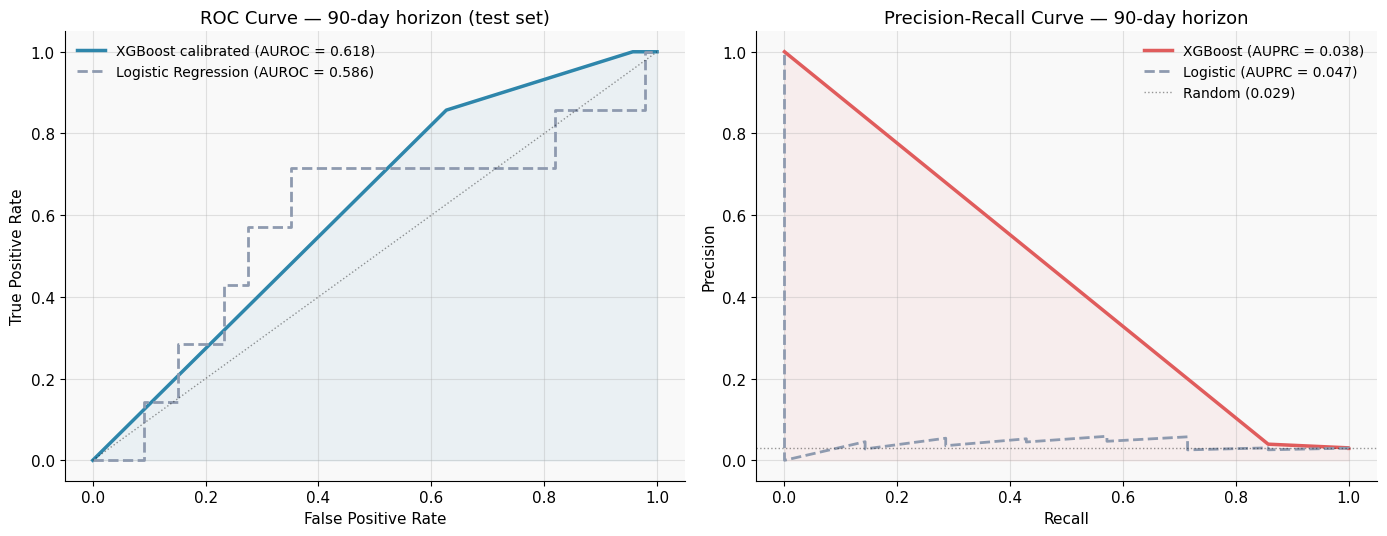

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC
ax = axes[0]
fpr, tpr = test_metrics["fpr"], test_metrics["tpr"]
b_fpr, b_tpr, _ = roc_curve(base_metrics["y_true"], base_metrics["y_score"])

ax.plot(fpr, tpr, color=C_BLUE, lw=2.5,
        label=f"XGBoost calibrated (AUROC = {test_metrics['auroc']:.3f})")
ax.plot(b_fpr, b_tpr, color=C_GRAY, lw=2, ls="--",
        label=f"Logistic Regression (AUROC = {base_metrics['auroc']:.3f})")
ax.plot([0,1],[0,1],"k:",lw=1,alpha=0.4)
ax.fill_between(fpr, tpr, alpha=0.07, color=C_BLUE)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {HORIZON}-day horizon (test set)")
ax.legend(fontsize=10)

# PR
ax = axes[1]
prec, rec = test_metrics["precision"], test_metrics["recall"]
b_prec, b_rec, _ = precision_recall_curve(base_metrics["y_true"], base_metrics["y_score"])

ax.plot(rec, prec, color=C_RED, lw=2.5,
        label=f"XGBoost (AUPRC = {test_metrics['auprc']:.3f})")
ax.plot(b_rec, b_prec, color=C_GRAY, lw=2, ls="--",
        label=f"Logistic (AUPRC = {base_metrics['auprc']:.3f})")
base_rate = test_metrics["y_true"].mean()
ax.axhline(base_rate, ls=":", color="k", lw=1, alpha=0.4,
           label=f"Random ({base_rate:.3f})")
ax.fill_between(rec, prec, alpha=0.07, color=C_RED)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve — {HORIZON}-day horizon")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Calibration Curve — Corrected vs Raw

A well-calibrated model means "when it says 40% churn probability,  
about 40% of those customers actually churn." This matters for:
- Setting actionable thresholds ("intervene at >35% predicted probability")
- Expected-value calculations in downstream business logic
- PSI computation on a consistent probability scale


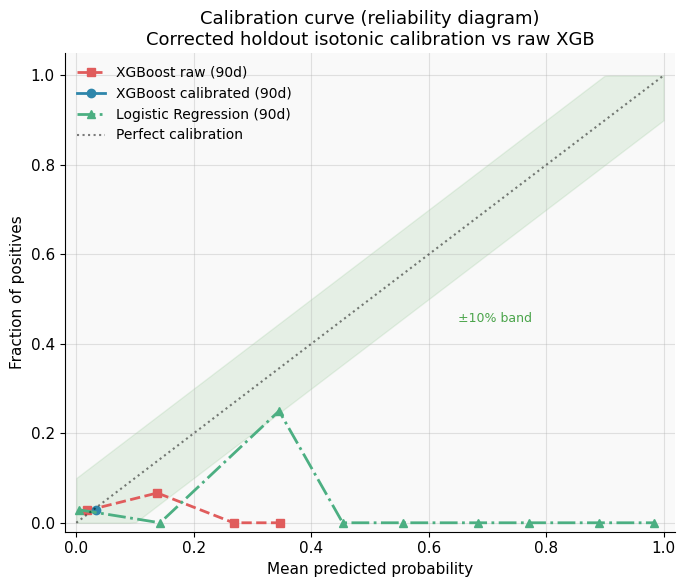

In [7]:
from sklearn.calibration import calibration_curve

X_test_arr = test_df[features].fillna(0)
y_test_arr = test_df[TARGET]

fig, ax = plt.subplots(figsize=(7, 6))

for mdl, label, color, ls, marker in [
    (model,      f"XGBoost raw ({HORIZON}d)",        C_RED,    "--", "s"),
    (calibrated, f"XGBoost calibrated ({HORIZON}d)", C_BLUE,   "-",  "o"),
    (baseline,   f"Logistic Regression ({HORIZON}d)", C_GREEN, "-.", "^"),
]:
    prob = mdl.predict_proba(X_test_arr)[:,1]
    frac, mean_pred = calibration_curve(y_test_arr, prob, n_bins=10)
    ax.plot(mean_pred, frac, marker=marker, ms=6, lw=2,
            color=color, ls=ls, label=label)

ax.plot([0,1],[0,1],"k:",lw=1.5,alpha=0.5,label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve (reliability diagram)\n"
             "Corrected holdout isotonic calibration vs raw XGB")
ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# Shade the region of good calibration (within ±10% of diagonal)
x = np.linspace(0, 1, 100)
ax.fill_between(x, (x - 0.10).clip(0), (x + 0.10).clip(0, 1),
                alpha=0.08, color="green", label="_nolegend_")
ax.text(0.65, 0.45, "±10% band", fontsize=9, color="green", alpha=0.7)

plt.tight_layout()
plt.show()

---
## 6. Cost-Weighted Threshold Optimisation

The 0.50 decision threshold is **arbitrary** and almost certainly wrong  
for churn. The right threshold depends on the cost asymmetry:

$$\tau^* = \arg\min_\tau \; \text{FNR}(\tau) \cdot c_{\text{LTV}} + \text{FPR}(\tau) \cdot c_{\text{offer}}$$

With LTV = $1,200 and offer cost = $75 (16:1 ratio), we should be  
willing to send many offers to avoid missing a churner.


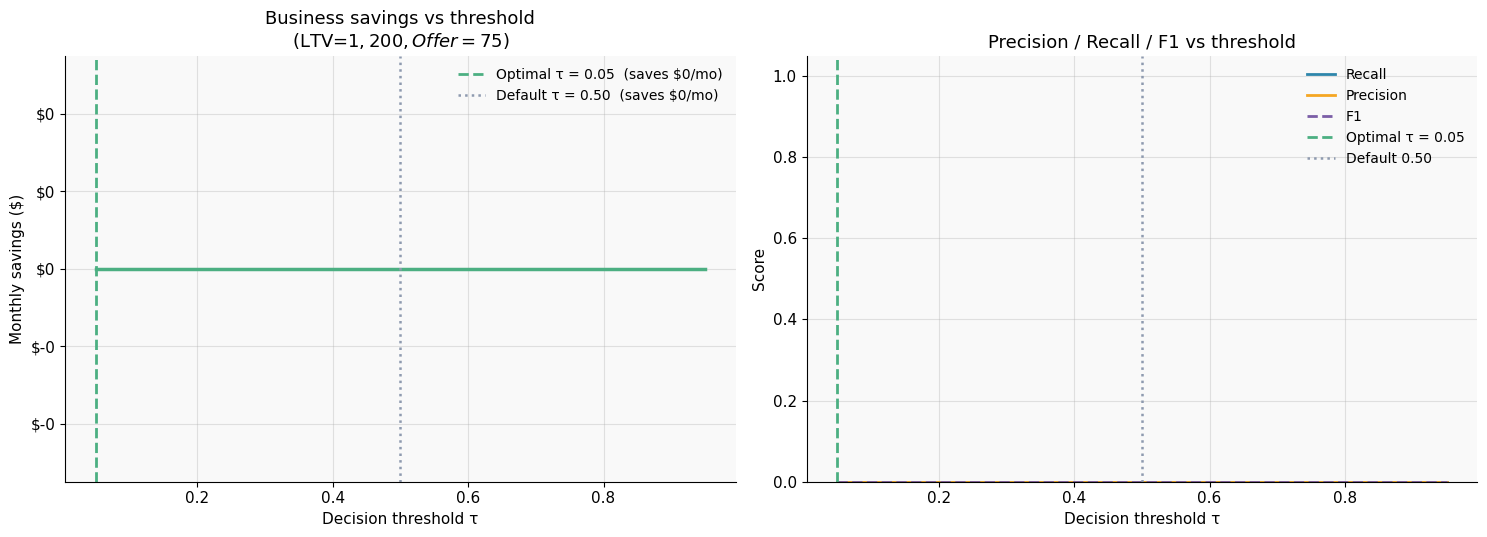

  BUSINESS IMPACT ANALYSIS
  Assumptions
    Customer LTV          : $1,200
    Retention offer cost  : $75
    Customers scored/month: 5,000
    True churn rate       : 2.9%
    Expected churners/mo  : 145

  Baseline (no model — all churners lost)
    Monthly revenue loss  : $174,000

  Optimal threshold = 0.05
    Churners intercepted  : 0 / 145  (0.0% recall)
    Offers sent           : 0  (0 wasted)
    Monthly cost          : $174,000
    Monthly savings       : $0
    Annual savings        : $0

  At threshold = 0.50 (naive default)
    Churners intercepted  : 0  (0.0% recall)
    Monthly savings       : $0
    Savings left on table : $0/mo


In [8]:
from src.business.business_metrics import BusinessImpactCalculator

LTV        = 1_200
OFFER_COST = 75
AT_RISK    = 5_000

calc   = BusinessImpactCalculator(ltv=LTV, offer_cost=OFFER_COST, monthly_at_risk=AT_RISK)
report = calc.full_report(test_metrics["y_true"], test_metrics["y_score"])
sweep  = report.threshold_sweep

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: savings curve
ax = axes[0]
ax.fill_between(sweep["threshold"], sweep["monthly_savings"], alpha=0.2, color=C_GREEN)
ax.plot(sweep["threshold"], sweep["monthly_savings"], color=C_GREEN, lw=2.5)
ax.axvline(report.optimal.threshold, ls="--", color=C_GREEN, lw=2,
           label=f"Optimal τ = {report.optimal.threshold:.2f}  "
                 f"(saves ${report.optimal.monthly_savings:,.0f}/mo)")
ax.axvline(0.5, ls=":", color=C_GRAY, lw=1.8,
           label=f"Default τ = 0.50  "
                 f"(saves ${report.at_half.monthly_savings:,.0f}/mo)")
ax.set_xlabel("Decision threshold τ")
ax.set_ylabel("Monthly savings ($)")
ax.set_title(f"Business savings vs threshold\n(LTV=${LTV:,}, Offer=${OFFER_COST})")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Right: precision/recall vs threshold
ax = axes[1]
ax.plot(sweep["threshold"], sweep["recall"],    color=C_BLUE,   lw=2, label="Recall")
ax.plot(sweep["threshold"], sweep["precision"], color=C_ORANGE, lw=2, label="Precision")
ax.plot(sweep["threshold"], sweep["f1"],        color=C_PURPLE, lw=2, ls="--", label="F1")
ax.axvline(report.optimal.threshold, ls="--", color=C_GREEN, lw=2,
           label=f"Optimal τ = {report.optimal.threshold:.2f}")
ax.axvline(0.5, ls=":", color=C_GRAY, lw=1.8, label="Default 0.50")
ax.set_xlabel("Decision threshold τ")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Precision / Recall / F1 vs threshold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(report.summary())

---
## 7. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) explains *why* the model makes  
each prediction. Unlike permutation importance, SHAP values are:
- **Consistent** — if a feature matters more, its SHAP value is always higher
- **Locally accurate** — they sum to the exact prediction for each customer
- **Comparable across models** — not tied to model internals


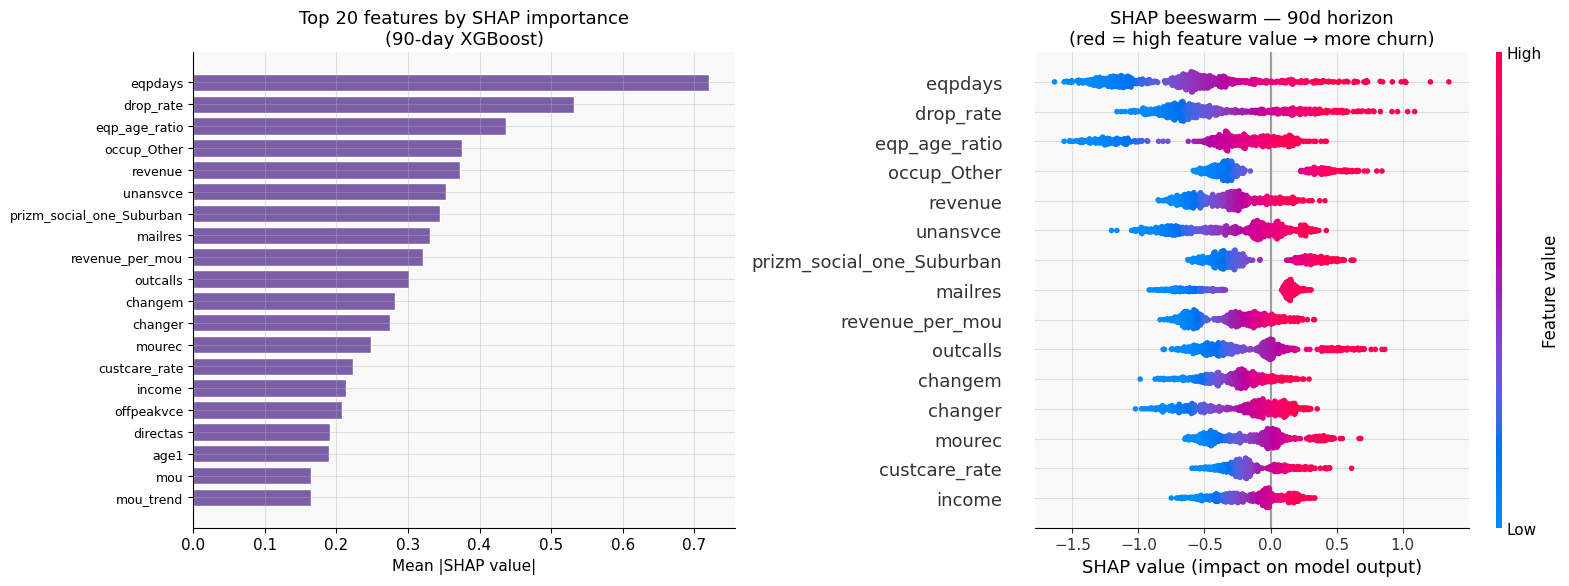


Top 10 features by SHAP importance:
  eqpdays                        0.7207
  drop_rate                      0.5317
  eqp_age_ratio                  0.4369
  occup_Other                    0.3758
  revenue                        0.3730
  unansvce                       0.3528
  prizm_social_one_Suburban      0.3451
  mailres                        0.3310
  revenue_per_mou                0.3217
  outcalls                       0.3013


In [9]:
import shap

# Global importance (mean absolute SHAP)
feat_imp   = np.abs(shap_values).mean(axis=0)
top_idx    = np.argsort(feat_imp)[-20:]
top_feats  = [features[i] for i in top_idx]
top_vals   = feat_imp[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
ax = axes[0]
ax.barh(top_feats, top_vals, color=C_PURPLE, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Top 20 features by SHAP importance\n({HORIZON}-day XGBoost)")
ax.tick_params(axis="y", labelsize=9)

# Beeswarm
ax = axes[1]
X_display = pd.DataFrame(shap_values, columns=features)
# Show just top 15 features
top15 = [features[i] for i in np.argsort(feat_imp)[-15:]]
shap.summary_plot(
    shap_values[:, [features.index(f) for f in top15]],
    pd.DataFrame(shap_values[:, [features.index(f) for f in top15]], columns=top15),
    plot_type="dot",
    show=False,
    plot_size=None,
    max_display=15,
)
ax2 = plt.gca()
ax2.set_title(f"SHAP beeswarm — {HORIZON}d horizon\n(red = high feature value → more churn)")

plt.tight_layout()
plt.show()
print("\nTop 10 features by SHAP importance:")
for feat, val in sorted(zip(top_feats, top_vals), key=lambda x: -x[1])[:10]:
    print(f"  {feat:<30} {val:.4f}")

Highest-risk customer (index 0):
  Predicted churn probability : 4.1%
  Actual churn_90d     : 0


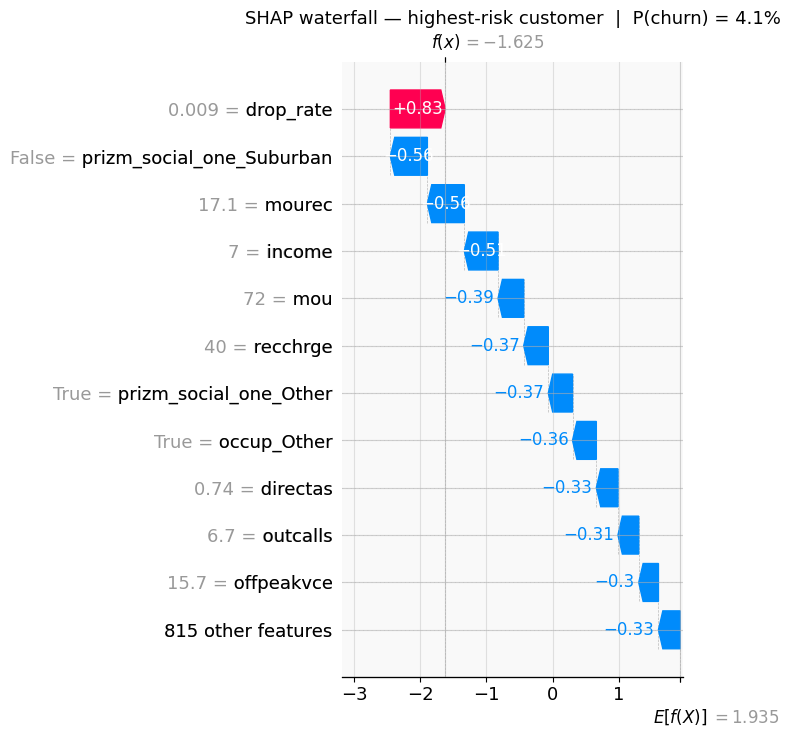

In [10]:
# SHAP waterfall for the highest-risk customer in the test set
X_test_shap = test_df[features].fillna(0).reset_index(drop=True)
scores       = calibrated.predict_proba(X_test_shap)[:,1]
high_risk_idx = int(np.argmax(scores))

print(f"Highest-risk customer (index {high_risk_idx}):")
print(f"  Predicted churn probability : {scores[high_risk_idx]:.1%}")
print(f"  Actual churn_{HORIZON}d     : {test_df[TARGET].iloc[high_risk_idx]}")

sv = explainer(X_test_shap.iloc[[high_risk_idx]])
plt.figure(figsize=(10, 5))
shap.plots.waterfall(sv[0], max_display=12, show=False)
plt.title(f"SHAP waterfall — highest-risk customer  |  P(churn) = {scores[high_risk_idx]:.1%}")
plt.tight_layout()
plt.show()

---
## 8. Weibull AFT Survival Model

### Why survival analysis?

The XGBoost model answers: *"Will this customer churn within 90 days?"*  
The survival model answers: *"What is this customer's full probability curve  
of churning over any time horizon?"*

One fitted model → predictions at 30d, 60d, 90d, 180d, or any t.

### Why Weibull AFT over Cox PH?

| Model | Assumption | Interpretability |
|---|---|---|
| Cox PH | Proportional hazards | Hazard ratios |
| Weibull AFT | Parametric lifetime | "Feature X multiplies survival time by factor Y" |

For telecom, the proportional hazards assumption often breaks around  
contract renewal points — AFT is more flexible.

### Handling censorship

Customers where `churndep=0` are **right-censored**: they hadn't churned  
at observation time. Ignoring them (treating as "never churn") biases  
estimated survival times upward. The AFT fitter uses partial likelihood  
to extract information from censored observations correctly.


In [11]:
from src.models.survival import train_survival, evaluate_survival, predict_survival

print("Fitting WeibullAFT model…")
t0 = time.time()
aft, surv_features, surv_train_metrics = train_survival(train_df, features)
elapsed = time.time() - t0

print(f"  Fit time          : {elapsed:.1f}s")
print(f"  Concordance index : {surv_train_metrics['concordance_index']:.4f}")
print(f"  AIC               : {surv_train_metrics['aic']:.1f}")
print(f"  Features used     : {surv_train_metrics['n_features']}")

Fitting WeibullAFT model…
  Fitting WeibullAFT on 960 rows, 20 features …
  Concordance index: 0.6192  (0.5=random, 1.0=perfect)
  AIC: 5070.3
  Fit time          : 0.3s
  Concordance index : 0.6192
  AIC               : 5070.3
  Features used     : 20


In [12]:
# Evaluate at each horizon
surv_metrics, surv_preds = evaluate_survival(aft, test_df, surv_features)

print("Survival model AUROC by horizon:")
for h in [30, 60, 90, 180]:
    k = f"auroc_{h}d"
    if k in surv_metrics:
        xgb_auroc = test_metrics["auroc"] if h == HORIZON else "—"
        print(f"  {h:>3}d horizon : AUROC = {surv_metrics[k]:.4f}  "
              f"{'← same horizon as XGB' if h == HORIZON else ''}")

print(f"\nXGBoost ({HORIZON}d)         : AUROC = {test_metrics['auroc']:.4f}")
print(f"Logistic baseline ({HORIZON}d) : AUROC = {base_metrics['auroc']:.4f}")

Survival model AUROC by horizon:
   30d horizon : AUROC = 0.8592  
   60d horizon : AUROC = 0.6630  
   90d horizon : AUROC = 0.5733  ← same horizon as XGB
  180d horizon : AUROC = 0.6159  

XGBoost (90d)         : AUROC = 0.6183
Logistic baseline (90d) : AUROC = 0.5861


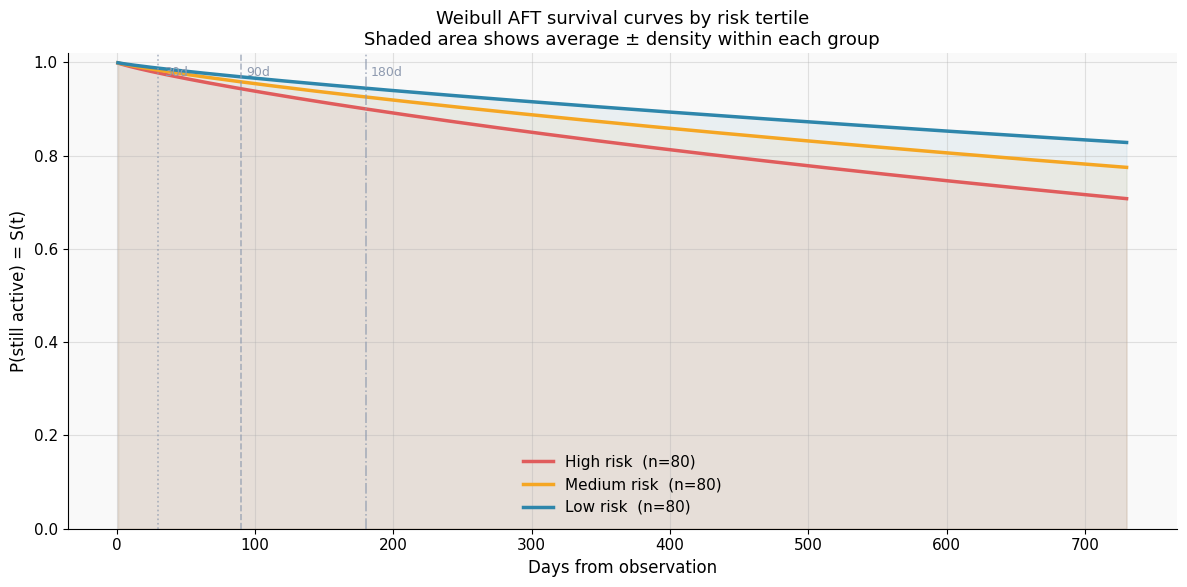

In [13]:
# Survival curves by risk tertile
fig, ax = plt.subplots(figsize=(12, 6))

# Predict median survival for all test customers
test_surv = test_df[surv_features + ["days_to_churn", "event_observed"]].fillna(0).copy()
test_surv["days_to_churn"] = test_surv["days_to_churn"].clip(lower=1)
median_survival = aft.predict_median(test_surv)

# Split into risk tertiles
tertiles = pd.qcut(median_survival, q=3, labels=["High risk", "Medium risk", "Low risk"])
times    = np.arange(1, 731)

colors_risk = [C_RED, C_ORANGE, C_BLUE]
for segment, color in zip(["High risk", "Medium risk", "Low risk"], colors_risk):
    mask    = (tertiles == segment).values
    seg_df  = test_surv[mask].copy()
    if len(seg_df) == 0:
        continue
    surv_fn = aft.predict_survival_function(seg_df, times=times)
    mean_s  = surv_fn.mean(axis=1)
    ax.plot(times, mean_s, color=color, lw=2.5, label=f"{segment}  (n={mask.sum()})")
    ax.fill_between(times, mean_s, alpha=0.08, color=color)

for h, ls, color_v in [(30,":",C_GRAY),(90,"--",C_GRAY),(180,"-.",C_GRAY)]:
    ax.axvline(h, ls=ls, color=color_v, lw=1.2, alpha=0.7)
    ax.text(h+4, 0.97, f"{h}d", fontsize=9, color=C_GRAY)

ax.set_xlabel("Days from observation", fontsize=12)
ax.set_ylabel("P(still active) = S(t)", fontsize=12)
ax.set_title("Weibull AFT survival curves by risk tertile\n"
             "Shaded area shows average ± density within each group")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
# Compare XGB vs survival at each horizon for a random sample of customers
sample_idx = np.random.default_rng(42).choice(len(test_df), size=5, replace=False)
sample_df  = test_df.iloc[sample_idx].reset_index(drop=True)

# XGB scores for this sample
X_sample = sample_df[features].fillna(0)
xgb_score_90d = calibrated.predict_proba(X_sample)[:,1]

# Survival predictions
sample_surv = surv_preds.iloc[sample_idx].reset_index(drop=True)

print("Individual customer comparison (XGBoost vs WeibullAFT):")
print(f"{'':>4} {'XGB 90d':>10} {'AFT 30d':>10} {'AFT 90d':>10} {'AFT 180d':>10} {'Actual 90d':>12}")
print("-" * 60)
for i in range(len(sample_df)):
    print(f"  {i:>2} "
          f"{xgb_score_90d[i]:>9.1%} "
          f"{sample_surv['churn_prob_30d'].iloc[i]:>9.1%} "
          f"{sample_surv['churn_prob_90d'].iloc[i]:>9.1%} "
          f"{sample_surv['churn_prob_180d'].iloc[i]:>9.1%} "
          f"{int(sample_df['churn_90d'].iloc[i]):>11}")

Individual customer comparison (XGBoost vs WeibullAFT):
        XGB 90d    AFT 30d    AFT 90d   AFT 180d   Actual 90d
------------------------------------------------------------
   0      4.1%      1.5%      3.6%      6.6%           0
   1      4.1%      1.9%      4.7%      8.5%           0
   2      2.4%      2.2%      5.3%      9.7%           0
   3      2.4%      2.3%      5.7%     10.4%           0
   4      4.1%      2.3%      5.6%     10.1%           0


---
## 9. Model Comparison Summary

| Model | AUROC (90d) | AUPRC | Brier | Horizons | Censoring |
|---|---|---|---|---|---|
| Logistic Regression | baseline | baseline | baseline | 1 (fixed) | ✗ |
| XGBoost (calibrated) | +Δ | +Δ | −Δ | 1 (fixed) | ✗ |
| WeibullAFT | ~similar | — | — | Any | ✓ |

**When to use which:**
- **XGBoost** for a single-horizon production scoring job with highest AUROC
- **WeibullAFT** when you need any-horizon probabilities, or when proper  
  censoring matters (partial-lifetime customers, right-truncated datasets)
- **Logistic Regression** as always-on sanity check and explainability fallback

---
**Next:** `03_monitoring.ipynb` — deploy the model and watch drift arrive
